# Kapitel 4 - Koduppgift 15 

##### Lägg en bildfil i samma mapp som programmet, i metoden predict_own_digit("image2.1.jpg") ska du ändra till valfribild OBS!! Den klarar inte av små smala linjer, utan bilden måste vara "tydlig"

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from PIL import Image, ImageOps

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import VotingClassifier


# Definierar en funktion som används senare
def display_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm).plot()
    plt.show()

(10000, 784)
(10000,)


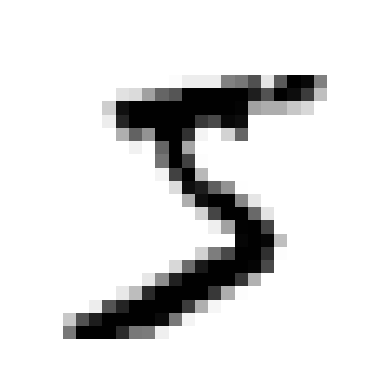

In [3]:
# Laddar data och inspekterar den
mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)

X = mnist["data"][:10000]
y = mnist["target"][:10000].astype(np.uint8)

print(X.shape)
print(y.shape)

some_digit = X[0]
some_digit_image = some_digit.reshape(28, 28)

plt.imshow(some_digit_image, cmap=mpl.cm.binary)
plt.axis("off")
plt.show()

In [4]:
# Delar upp data
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=2000, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=2000, random_state=42)

# Skalar data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [5]:
# Skapar modeller
logreg_clf = LogisticRegression(max_iter=1000)
random_forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)
extra_trees_clf = ExtraTreesClassifier(n_estimators=100, random_state=42)

named_estimators = [
    ("logreg_clf", logreg_clf),
    ("random_forest_clf", random_forest_clf),
    ("extra_trees_clf", extra_trees_clf)
]

voting_clf = VotingClassifier(named_estimators, voting='hard')

models = [logreg_clf, random_forest_clf, extra_trees_clf, voting_clf]


In [6]:
# Tränar modellerna
for model in models:
    model.fit(X_train, y_train)

print("Accuracy for each model")
model_names = ["Logistic Regression", "Random Forest", "Extra Trees", "VotingClassifier"]

for name, model in zip(model_names, models):
    score = model.score(X_val, y_val)
    print(f"{name:20s}: {score:.4f}")

Accuracy for each model
Logistic Regression : 0.8800
Random Forest       : 0.9380
Extra Trees         : 0.9400
VotingClassifier    : 0.9395


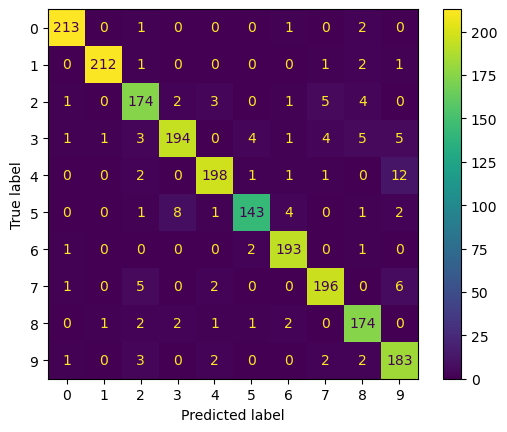

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       217
           1       0.99      0.98      0.98       217
           2       0.91      0.92      0.91       190
           3       0.94      0.89      0.92       218
           4       0.96      0.92      0.94       215
           5       0.95      0.89      0.92       160
           6       0.95      0.98      0.96       197
           7       0.94      0.93      0.94       210
           8       0.91      0.95      0.93       183
           9       0.88      0.95      0.91       193

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000



In [7]:
# Utvärderar Extra Trees på valideringsdata
et_pred_val = extra_trees_clf.predict(X_val)
display_confusion_matrix(y_val, et_pred_val)
print(classification_report(y_val, et_pred_val))

In [8]:
# Tränar om modellen på train + validation data
X_train_val = scaler.fit_transform(X_train_val)
X_test = scaler.transform(X_test)

extra_trees_clf.fit(X_train_val, y_train_val)

ExtraTreesClassifier(random_state=42)

In [9]:
# Utvärderar modellen på testdata
et_pred_test = extra_trees_clf.predict(X_test)

In [10]:
# Tränar slutlig modell på alla 10000 bilder
scaler_2 = StandardScaler()
X = scaler_2.fit_transform(X)
extra_trees_clf.fit(X, y)

ExtraTreesClassifier(random_state=42)

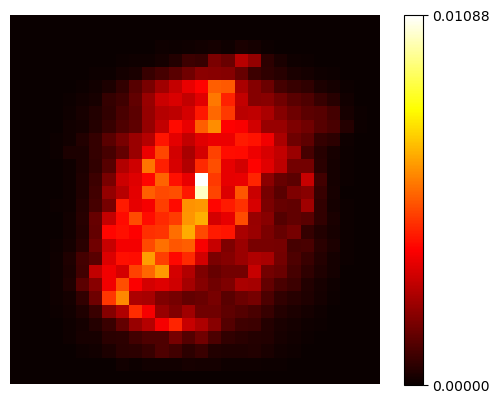

In [11]:
# Funktion från boken för att visa bild
def plot_digit(data):
    image = data.reshape(28, 28)
    plt.imshow(image, cmap=mpl.cm.hot, interpolation="nearest")
    plt.axis("off")


plot_digit(extra_trees_clf.feature_importances_)
cbar = plt.colorbar(
    ticks=[
        extra_trees_clf.feature_importances_.min(),
        extra_trees_clf.feature_importances_.max()
    ]
)
plt.show()

In [12]:
# Denna funktion läser in en egen bild, t.ex. från mobilen,
# och gör om den till samma format som MNIST (28x28 pixlar)
def preprocess_own_image(image_path):
    # Öppnar bilden och gör om den till gråskala
    img = Image.open(image_path).convert("L")

    # Inverterar bilden så att siffran blir ljus och bakgrunden mörk
    # eftersom MNIST-bilderna ser ut ungefär så
    img = ImageOps.invert(img)

    # Beskär bort onödiga kanter runt siffran
    bbox = img.getbbox()
    if bbox is not None:
        img = img.crop(bbox)

    # Gör bilden kvadratisk genom att lägga till svart bakgrund
    width, height = img.size
    max_side = max(width, height)
    square_img = Image.new("L", (max_side, max_side), color=0)

    x_offset = (max_side - width) // 2
    y_offset = (max_side - height) // 2
    square_img.paste(img, (x_offset, y_offset))

    # Ändrar storlek till 28x28 pixlar
    img_28 = square_img.resize((28, 28))

    # Gör om bilden till en numpy-array
    img_array = np.array(img_28).astype(np.float64)

    # Visar den behandlade bilden
    plt.imshow(img_array, cmap=mpl.cm.binary)
    plt.axis("off")
    plt.show()

    # Gör om bilden till samma format som MNIST-data: 1 rad och 784 kolumner
    img_flat = img_array.reshape(1, 784)

    return img_flat

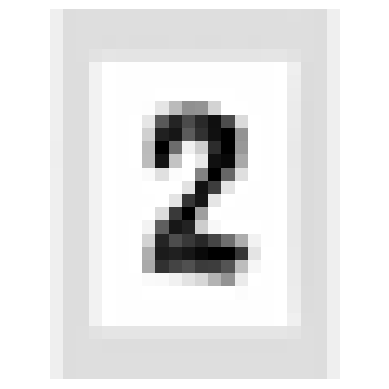

Predicted digit is 2


In [13]:
# Denna funktion predikterar vilken siffra den egna bilden föreställer
def predict_own_digit(image_path):
    own_digit = preprocess_own_image(image_path)

    # Skalar bilden med samma scaler som användes vid träningen
    own_digit = scaler_2.transform(own_digit)

    # Gör prediktion
    prediction = extra_trees_clf.predict(own_digit)

    # Skriver ut resultatet
    print("Predicted digit is", prediction[0])

predict_own_digit("image2.1.jpg")